### Customer Segmentation

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"   # Fix for KMeans error

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [4]:
# 1. Load Dataset ----
df = pd.read_csv(r"C:\Users\PAVITHRA H R\Desktop\Internship\Mall_customers.csv")

print("\n--- Dataset Preview ---")
print(df.head())



--- Dataset Preview ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
# 2. Select Features ----
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [8]:
#3. Scaling ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


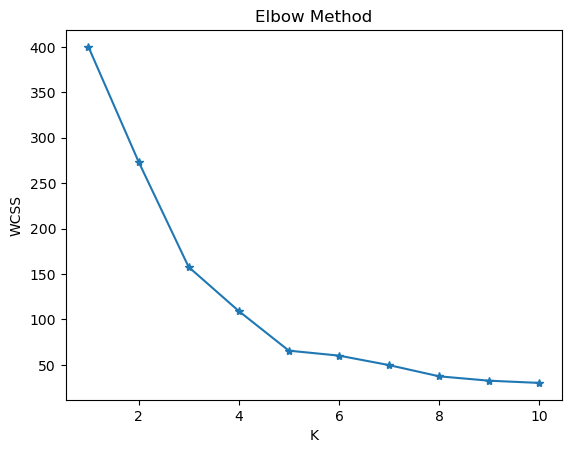

In [18]:
# 4. Elbow Method ----
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='*')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [13]:
# 5. Apply KMeans ----
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


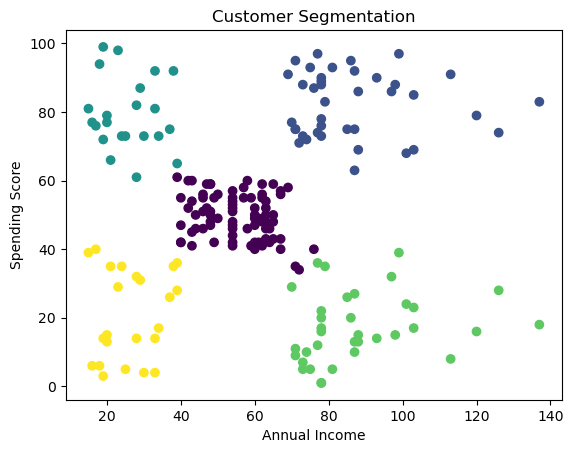

In [14]:
# 6. Visualization ----
plt.figure()
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

In [15]:
# 7. Cluster Centers ----
print("\nCluster Centers:")
print(kmeans.cluster_centers_)


Cluster Centers:
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
